# SHAP Analysis — Vectyfi Radar XGBoost

Explain predictions of the XGBoost model trained to predict EU public tender award (`awarded` = 1 vs 0).

**Sections:**
1. Setup & data rebuild
2. SHAP explainer
3. Global importance (beeswarm + bar)
4. Dependence plots (top features)
5. Single-prediction waterfall

## 1. Setup & Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

shap.initjs()
print("✅ All imports loaded")

✅ All imports loaded


## 2. Rebuild Data & Model

Replicates the exact preprocessing from the main notebook so SHAP runs against the same model.

In [38]:
FILE_PATH = '/Users/basile/code/Tescoa00/raw_data/export_CFC_2018_2023.csv'

df_raw = pd.read_csv(FILE_PATH, nrows=500_000, low_memory=False)
print(f"✅ Loaded: {df_raw.shape[0]:,} rows * {df_raw.shape[1]} columns")

✅ Loaded: 500,000 rows * 64 columns


In [39]:
if 'WIN_NAME' in df_raw.columns and 'AWARD_VALUE_EURO' in df_raw.columns:
    df_raw['y'] = ((df_raw['WIN_NAME'].notna()) | (df_raw['AWARD_VALUE_EURO'] > 0)).astype(int)
elif 'FUTURE_CAN_ID' in df_raw.columns:
    df_raw['y'] = df_raw['FUTURE_CAN_ID'].notna().astype(int)
else:
    raise ValueError('No valid target columns found in dataset!')

# --- Target Distribution ---
n_pos = df_raw['y'].sum()
n_neg = len(df_raw) - n_pos
imbalance_ratio = n_neg / n_pos

print(f'\n{"="*50}')
print(f'  Awarded (y=1):     {n_pos:>8,}  ({n_pos/len(df_raw)*100:.1f}%)')
print(f'  Not Awarded (y=0): {n_neg:>8,}  ({n_neg/len(df_raw)*100:.1f}%)')
print(f'  Imbalance Ratio:   1 : {imbalance_ratio:.4f}')
print(f'{"="*50}')

# --- The Leakage Exorcism ---
CAN_LEAK_COLUMNS = [
    'WIN_NAME', 'WIN_NATIONALID', 'WIN_ADDRESS', 'WIN_TOWN', 'WIN_POSTAL_CODE',
    'WIN_COUNTRY_CODE', 'B_AWARDED_TO_A_GROUP', 'B_CONTRACTOR_SME', 'NUMBER_OFFERS',
    'NUMBER_TENDERS_SME', 'NUMBER_TENDERS_OTHER_EU', 'NUMBER_TENDERS_NON_EU',
    'NUMBER_OFFERS_ELECTR', 'AWARD_VALUE_EURO', 'AWARD_VALUE_EURO_FIN_1',
    'AWARD_EST_VALUE_EURO', 'DT_AWARD', 'ID_AWARD', 'B_SUBCONTRACTED',
    'INFO_ON_NON_AWARD', 'CONTRACT_NUMBER', 'FUTURE_CAN_ID', 'FUTURE_CAN_ID_ESTIMATED',
    'VALUE_EURO_FIN_1', 'VALUE_EURO_FIN_2',
]

FEATURES = [col for col in df_raw.columns if col not in CAN_LEAK_COLUMNS]
df = df_raw[[c for c in FEATURES if c in df_raw.columns]].copy()
print(f"✅ Loaded: {df.shape[0]:,} rows * {df.shape[1]} columns")


  Awarded (y=1):      439,928  (88.0%)
  Not Awarded (y=0):   60,072  (12.0%)
  Imbalance Ratio:   1 : 0.1365
✅ Loaded: 500,000 rows * 61 columns


In [40]:
print(df.columns.tolist())

['ID_NOTICE_CN', 'TED_NOTICE_URL', 'YEAR', 'ID_TYPE', 'DT_DISPATCH', 'XSD_VERSION', 'CANCELLED', 'CORRECTIONS', 'B_MULTIPLE_CAE', 'CAE_NAME', 'CAE_NATIONALID', 'CAE_ADDRESS', 'CAE_TOWN', 'CAE_POSTAL_CODE', 'ISO_COUNTRY_CODE', 'B_MULTIPLE_COUNTRY', 'ISO_COUNTRY_CODE_ALL', 'CAE_TYPE', 'EU_INST_CODE', 'MAIN_ACTIVITY', 'B_ON_BEHALF', 'B_INVOLVES_JOINT_PROCUREMENT', 'B_AWARDED_BY_CENTRAL_BODY', 'TYPE_OF_CONTRACT', 'TAL_LOCATION_NUTS', 'B_FRA_AGREEMENT', 'FRA_ESTIMATED', 'B_FRA_SINGLE_OPERATOR', 'FRA_NUMBER_OPERATORS', 'FRA_NUMBER_MAX_OPERATORS', 'B_DYN_PURCH_SYST', 'CPV', 'ID_LOT', 'ADDITIONAL_CPVS', 'B_GPA', 'LOTS_NUMBER', 'LOTS_SUBMISSION', 'B_VARIANTS', 'VALUE_EURO', 'B_OPTIONS', 'B_EU_FUNDS', 'B_RENEWALS', 'DURATION', 'CONTRACT_START', 'CONTRACT_COMPLETION', 'TOP_TYPE', 'B_ACCELERATED', 'ENV_OPERATORS', 'ENV_MIN_OPERATORS', 'ENV_MAX_OPERATORS', 'CRIT_CODE', 'CRIT_PRICE_WEIGHT', 'CRIT_CRITERIA', 'CRIT_WEIGHTS', 'B_ELECTRONIC_AUCTION', 'DT_APPLICATIONS', 'B_LANGUAGE_ANY_EC', 'ADMIN_LANGUA

### Features engineering

In [41]:
# Date features (only if columns survived the leakage filter)
for col in ['DT_DISPATCH', 'DT_APPLICATIONS']:
    if col in df.columns and not pd.api.types.is_datetime64_any_dtype(df[col]):
        df[col] = pd.to_datetime(df[col], dayfirst=True, format='mixed', errors='coerce')

if 'cpv4' not in df.columns:
    df['cpv4'] = df['CPV'].astype(str).str[:4]
if 'month_dispatch' not in df.columns:
    df['month_dispatch'] = df['DT_DISPATCH'].dt.month if 'DT_DISPATCH' in df.columns else 0
if 'is_end_of_year' not in df.columns:
    df['is_end_of_year'] = df['month_dispatch'].isin([11, 12]).astype(int)
if 'days_to_deadline' not in df.columns:
    df['days_to_deadline'] = (
        (df['DT_APPLICATIONS'] - df['DT_DISPATCH']).dt.days.clip(0, 365).fillna(30)
        if 'DT_DISPATCH' in df.columns and 'DT_APPLICATIONS' in df.columns else 30
    )
if 'has_value' not in df.columns:
    df['has_value'] = (df['VALUE_EURO'] > 0).astype(int)
if 'has_corrections' not in df.columns:
    df['has_corrections'] = (df['CORRECTIONS'] > 0).astype(int)

df = df.drop(columns=['DT_DISPATCH', 'DT_APPLICATIONS'], errors='ignore')

# Encode categoricals
cat_cols = df.select_dtypes(include=['object', 'str']).columns.tolist()
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le

X = df.drop(columns=['y']).fillna(0)
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (400000, 64), Test: (100000, 64)


In [42]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
)
xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=50)
print("✅ Model trained")

[0]	validation_0-logloss:0.35064
[50]	validation_0-logloss:0.21684
[100]	validation_0-logloss:0.19384
[150]	validation_0-logloss:0.17778
[200]	validation_0-logloss:0.16799
[250]	validation_0-logloss:0.15856
[299]	validation_0-logloss:0.15127
✅ Model trained


In [53]:
from sklearn.inspection import permutation_importance
pi = permutation_importance(xgb, X_test, y_test, n_repeats=10, random_state=42)

pi_df = pd.DataFrame({
    "feature":    X_test.columns,
    "importance": pi.importances_mean,
    "std":        pi.importances_std
}).sort_values("importance", ascending=False)

# Afficher le tableau
print(pi_df.to_string(index=False))

# Features qui font du bruit (importance négative ou nulle)
print("\n⚠️ Features inutiles ou nuisibles:")
print(pi_df[pi_df["importance"] <= 0])

                     feature    importance      std
                 LOTS_NUMBER  2.471700e-02 0.000295
      ADMIN_LANGUAGES_TENDER  1.674400e-02 0.000293
                    CAE_NAME  7.994000e-03 0.000243
                 CAE_ADDRESS  7.966000e-03 0.000209
           TAL_LOCATION_NUTS  7.166000e-03 0.000276
            days_to_deadline  6.837000e-03 0.000185
                    CAE_TOWN  6.127000e-03 0.000322
             CAE_POSTAL_CODE  6.019000e-03 0.000112
              CAE_NATIONALID  5.823000e-03 0.000127
                ID_NOTICE_CN  4.651000e-03 0.000139
              TED_NOTICE_URL  4.161000e-03 0.000124
                         CPV  3.511000e-03 0.000166
            ISO_COUNTRY_CODE  3.487000e-03 0.000153
                  VALUE_EURO  3.193000e-03 0.000184
                        cpv4  2.472000e-03 0.000127
                        YEAR  2.443000e-03 0.000149
                    DURATION  2.194000e-03 0.000188
                   CRIT_CODE  2.073000e-03 0.000172
            

In [43]:
y_prob = xgb.predict_proba(X_test)[:, 1]
roc = roc_auc_score(y_test, y_prob)
pr = average_precision_score(y_test, y_prob)

print(f"ROC-AUC: {roc:.4f} | PR-AUC: {pr:.4f}")

ROC-AUC: 0.9665 | PR-AUC: 0.9952


## 3. SHAP Explainer

We use `TreeExplainer` (exact, fast for XGBoost). We sample 5 000 test rows to keep plots readable.

In [44]:
SAMPLE_SIZE = 5_000
rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X_test), size=SAMPLE_SIZE, replace=False)
X_sample = X_test.iloc[sample_idx]

explainer = shap.TreeExplainer(xgb)
shap_values = explainer(X_sample)   # returns Explanation object

print(f"SHAP values shape: {shap_values.values.shape}")
print(f"Base value (log-odds): {shap_values.base_values[0]:.4f}")

SHAP values shape: (5000, 64)
Base value (log-odds): 2.0648


## 4. Global Feature Importance

### 4a. Beeswarm plot — shows impact distribution per feature

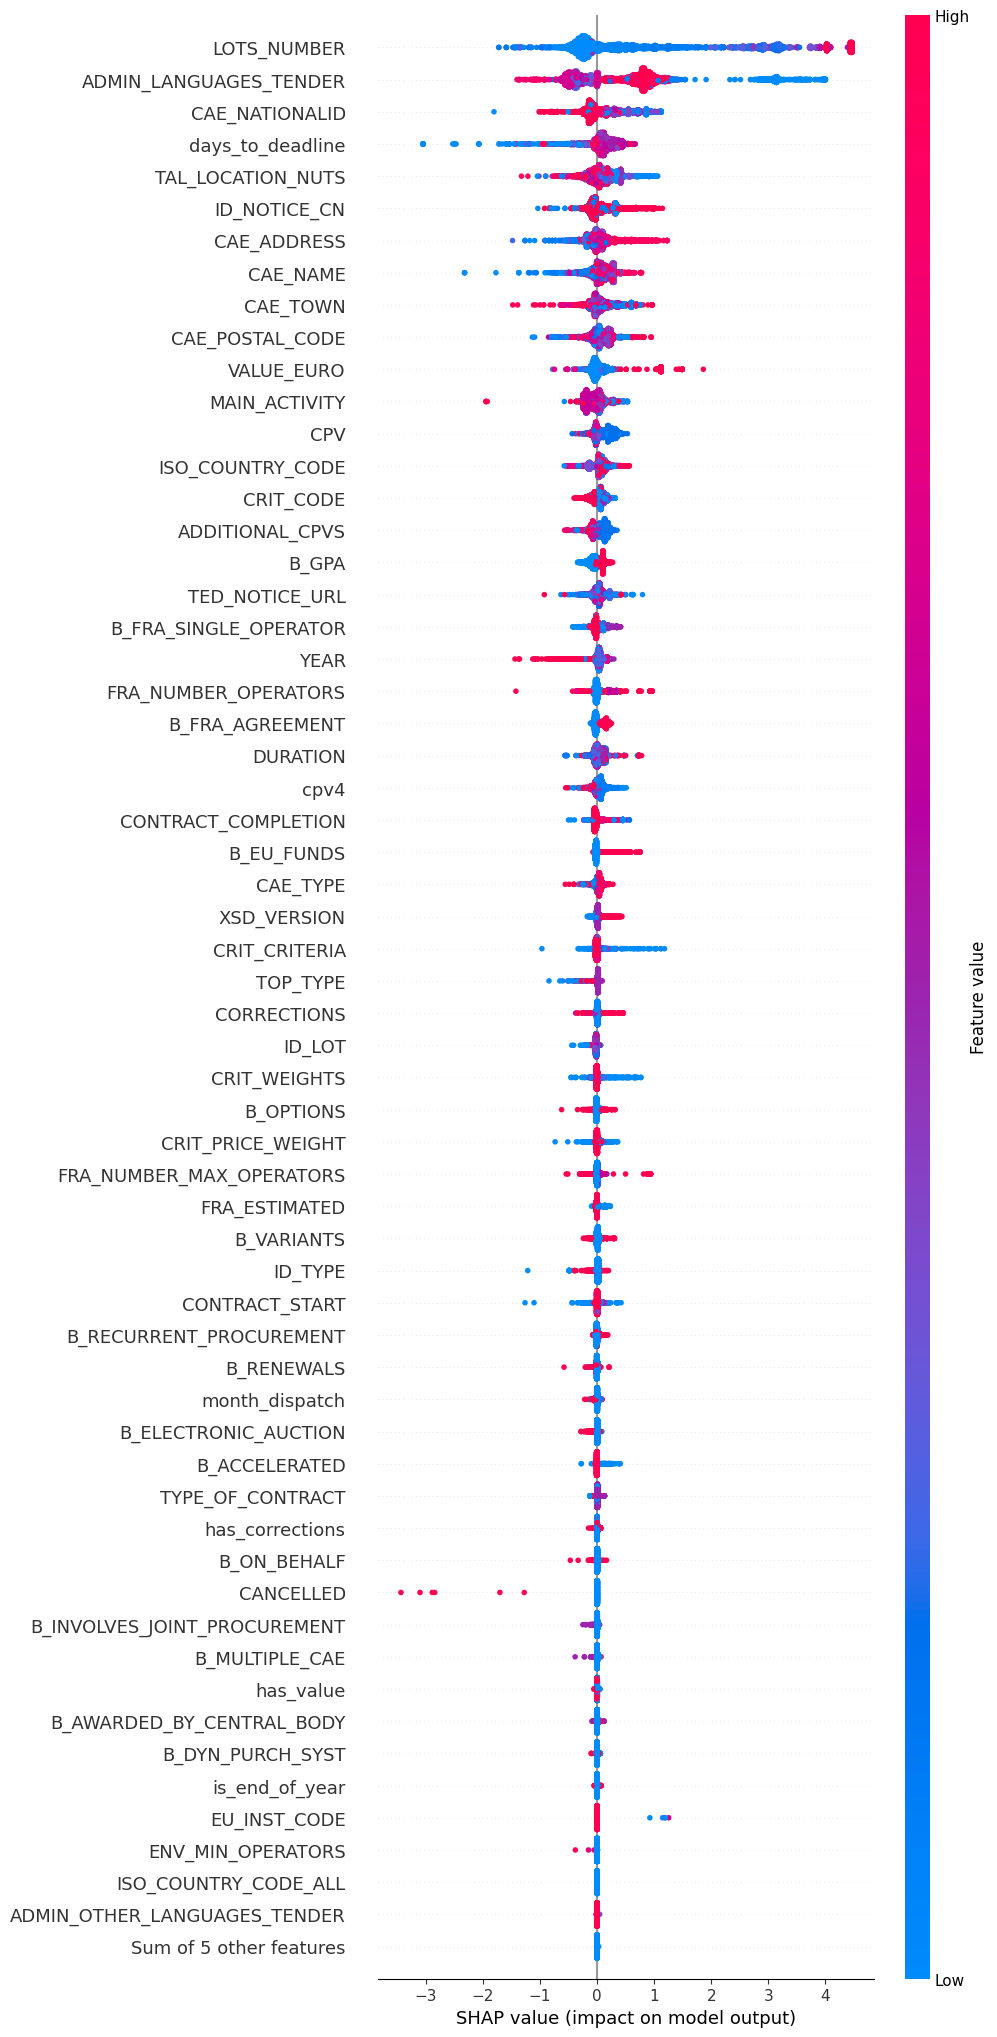

In [45]:
shap.plots.beeswarm(shap_values, max_display=60, show=True)

### 4b. Bar plot — mean |SHAP| per feature (simpler ranking)

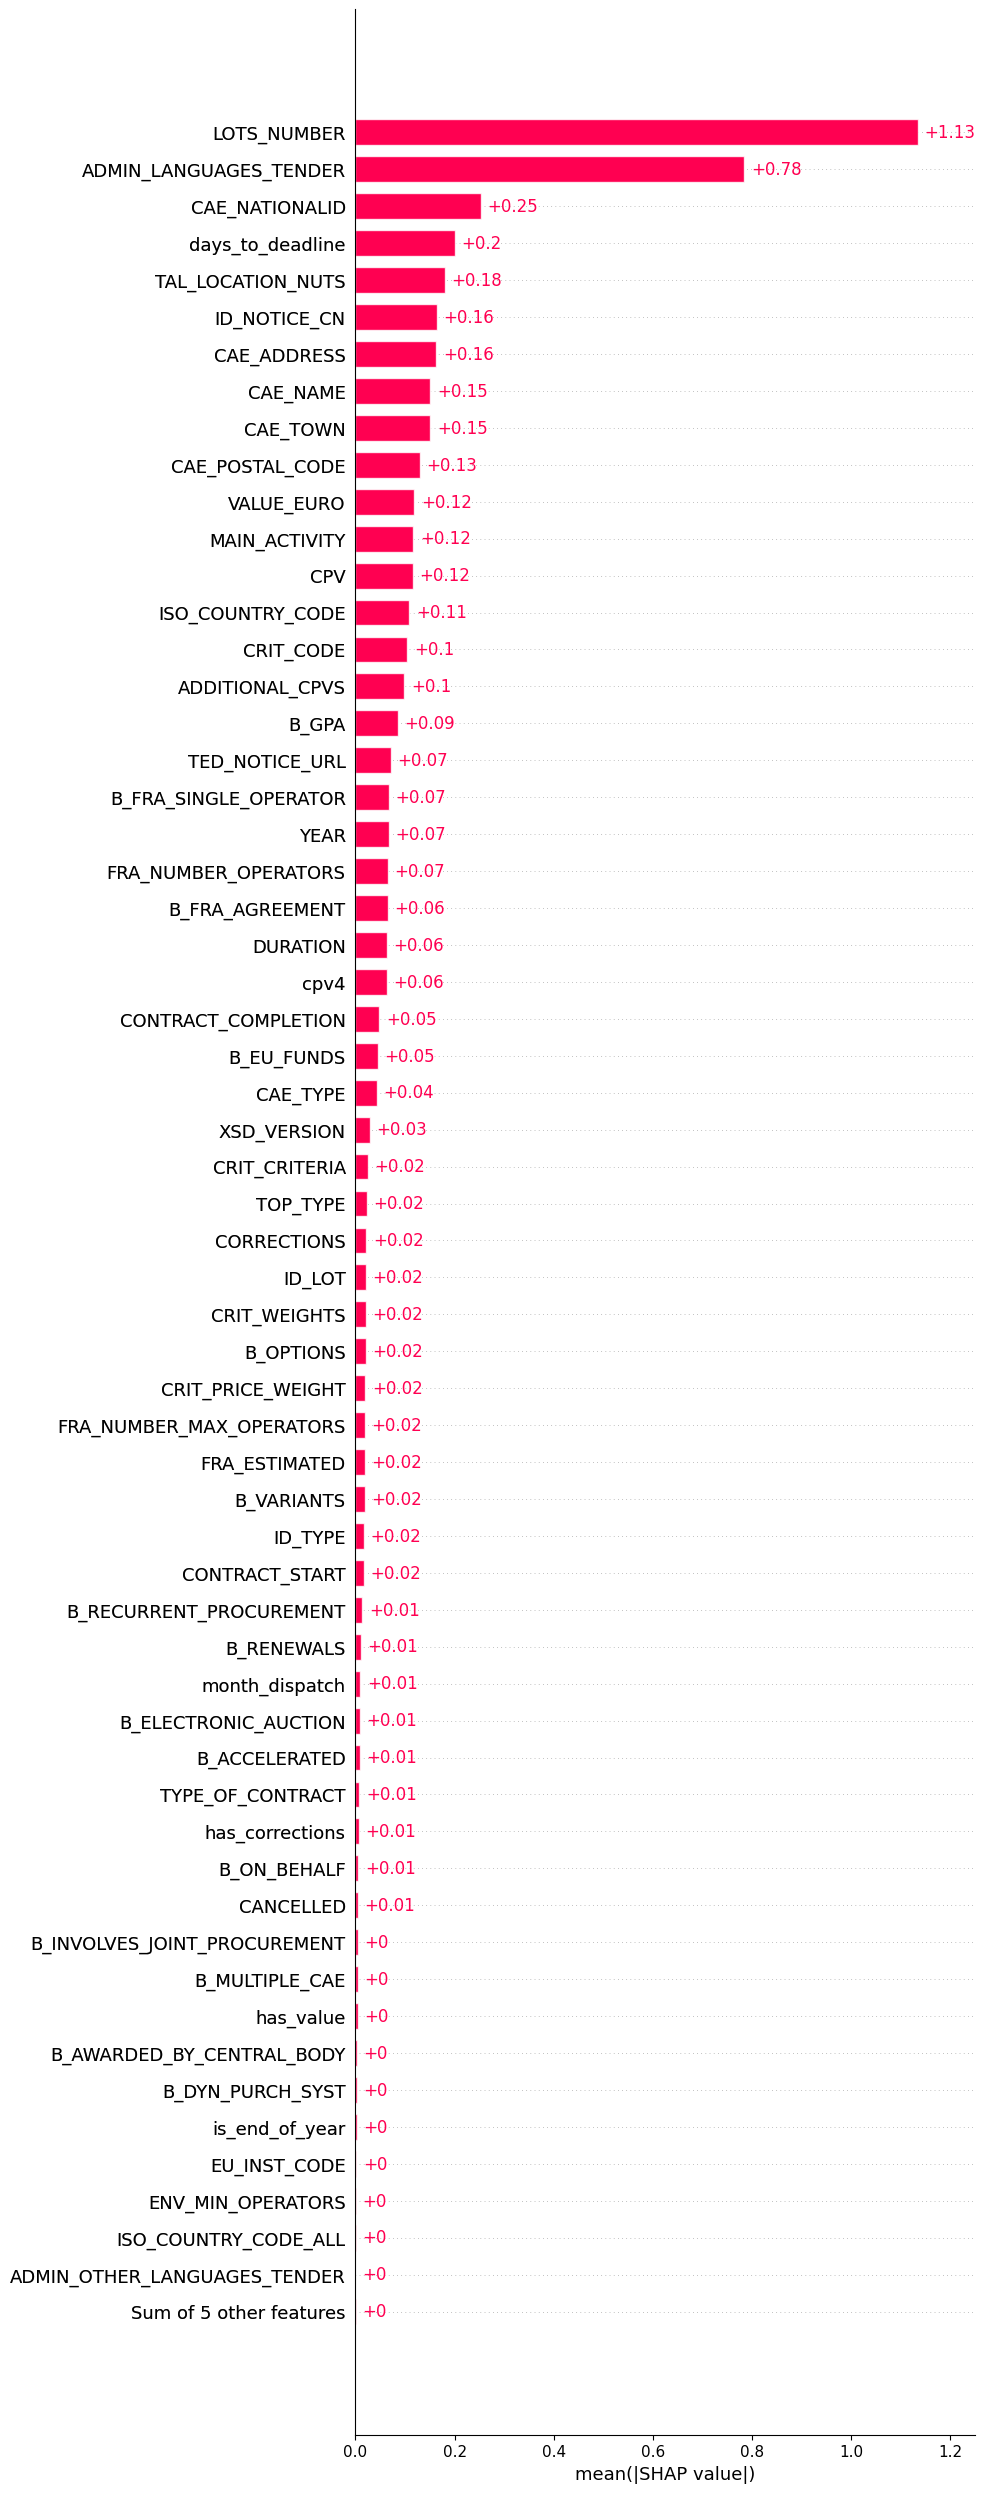

In [46]:
shap.plots.bar(shap_values, max_display=60, show=True)

## 5. Dependence Plots

How each top feature's value relates to its SHAP impact. The color encodes the most interacting feature (chosen automatically).

Top 5 features: ['LOTS_NUMBER', 'ADMIN_LANGUAGES_TENDER', 'CAE_NATIONALID', 'days_to_deadline', 'TAL_LOCATION_NUTS']


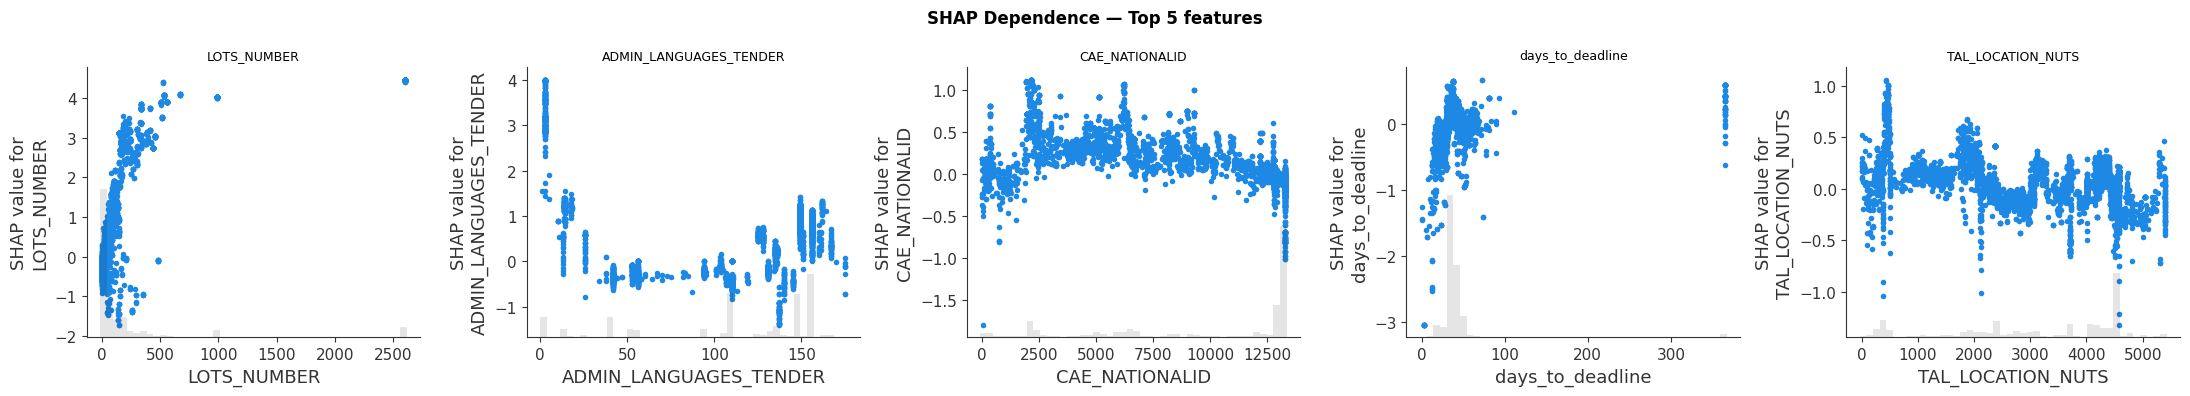

In [47]:
# Top-5 features by mean |SHAP|
mean_abs = np.abs(shap_values.values).mean(axis=0)
top5_features = X_sample.columns[np.argsort(mean_abs)[::-1][:5]].tolist()
print("Top 5 features:", top5_features)

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, feat in zip(axes, top5_features):
    shap.plots.scatter(shap_values[:, feat], ax=ax, show=False)
    ax.set_title(feat, fontsize=9)
plt.suptitle("SHAP Dependence — Top 5 features", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Waterfall — Single Prediction Explanation

Inspect one individual prediction (edit `ROW` to pick another).

Row 0 | True label: 1 | Predicted P(awarded): 1.000


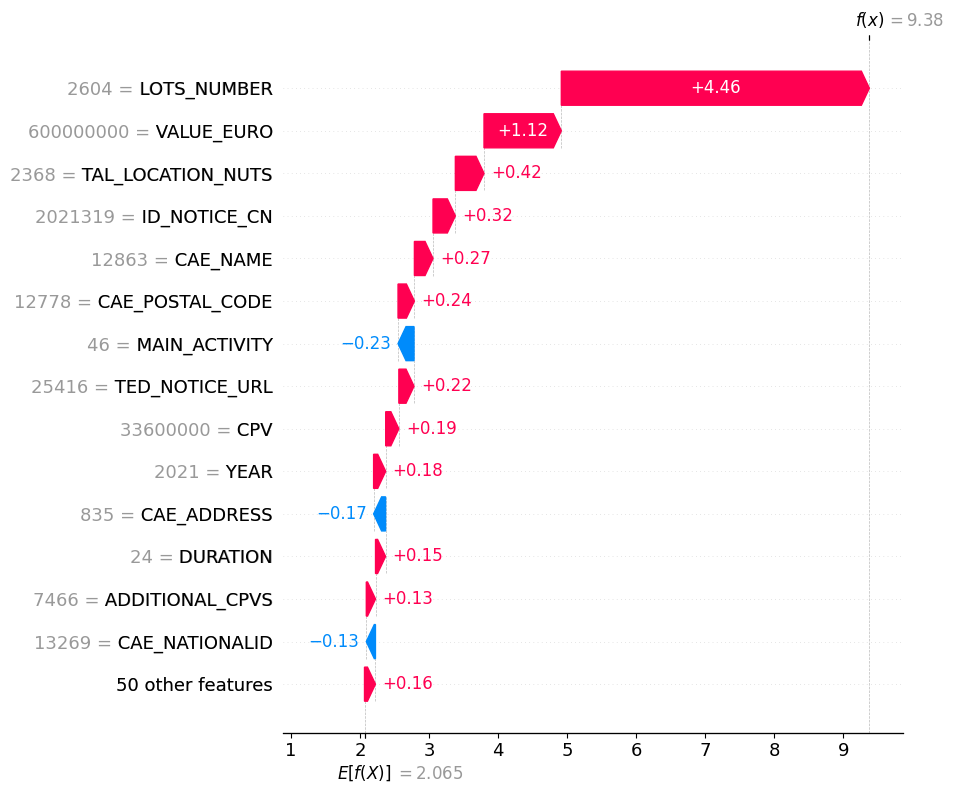

In [48]:
ROW = 0   # change to any index in [0, SAMPLE_SIZE)

pred_prob = xgb.predict_proba(X_sample.iloc[[ROW]])[0, 1]
true_label = y_test.iloc[sample_idx[ROW]]
print(f"Row {ROW} | True label: {true_label} | Predicted P(awarded): {pred_prob:.3f}")

shap.plots.waterfall(shap_values[ROW], max_display=15, show=True)

## 7. SHAP Values Table

Raw SHAP values for the sample — useful for downstream analysis or export.

In [49]:
shap_df = pd.DataFrame(shap_values.values, columns=X_sample.columns)
shap_df.insert(0, 'awarded_true', y_test.iloc[sample_idx].values)
shap_df.insert(1, 'pred_prob', xgb.predict_proba(X_sample)[:, 1])

print(shap_df.shape)
shap_df.head()

(5000, 66)


,awarded_true,pred_prob,ID_NOTICE_CN,TED_NOTICE_URL,YEAR,ID_TYPE,XSD_VERSION,CANCELLED,CORRECTIONS,B_MULTIPLE_CAE,...,B_LANGUAGE_ANY_EC,ADMIN_LANGUAGES_TENDER,ADMIN_OTHER_LANGUAGES_TENDER,B_RECURRENT_PROCUREMENT,cpv4,month_dispatch,is_end_of_year,days_to_deadline,has_value,has_corrections
0,1,0.999916,0.323402,0.219633,0.175159,0.023583,0.017208,0.001808,0.004012,0.012045,...,0.000006,0.002103,-0.000014,-0.009829,0.070721,-0.033142,-0.013204,-0.021830,-0.003319,0.003836
1,1,0.966151,0.081291,0.016300,0.011318,0.004967,0.013517,0.002775,-0.024186,0.000170,...,0.000004,0.195785,-0.000018,-0.020109,0.058629,0.011017,0.000529,0.135761,-0.007735,0.006505
2,1,0.955092,0.064683,0.012520,0.050953,0.007597,0.009451,0.003215,0.018042,-0.001584,...,0.000007,-0.256195,-0.000018,-0.006274,-0.060489,0.004176,0.000406,0.146034,-0.006036,0.000485
3,1,0.999977,-0.104347,0.086962,0.124078,0.022476,0.048608,0.001705,0.032654,0.000442,...,0.000006,3.173587,-0.000013,0.002988,0.082019,0.006214,-0.000170,0.311846,0.002036,0.000077
4,1,0.745645,0.001865,0.022642,-0.024169,0.002646,0.010237,0.002646,-0.005375,-0.000020,...,0.000012,-0.517244,-0.000016,-0.028823,0.244512,0.005489,0.008538,-0.139368,0.005377,-0.000528
